Processing file: db2_sb10\S10_E1_A1.mat


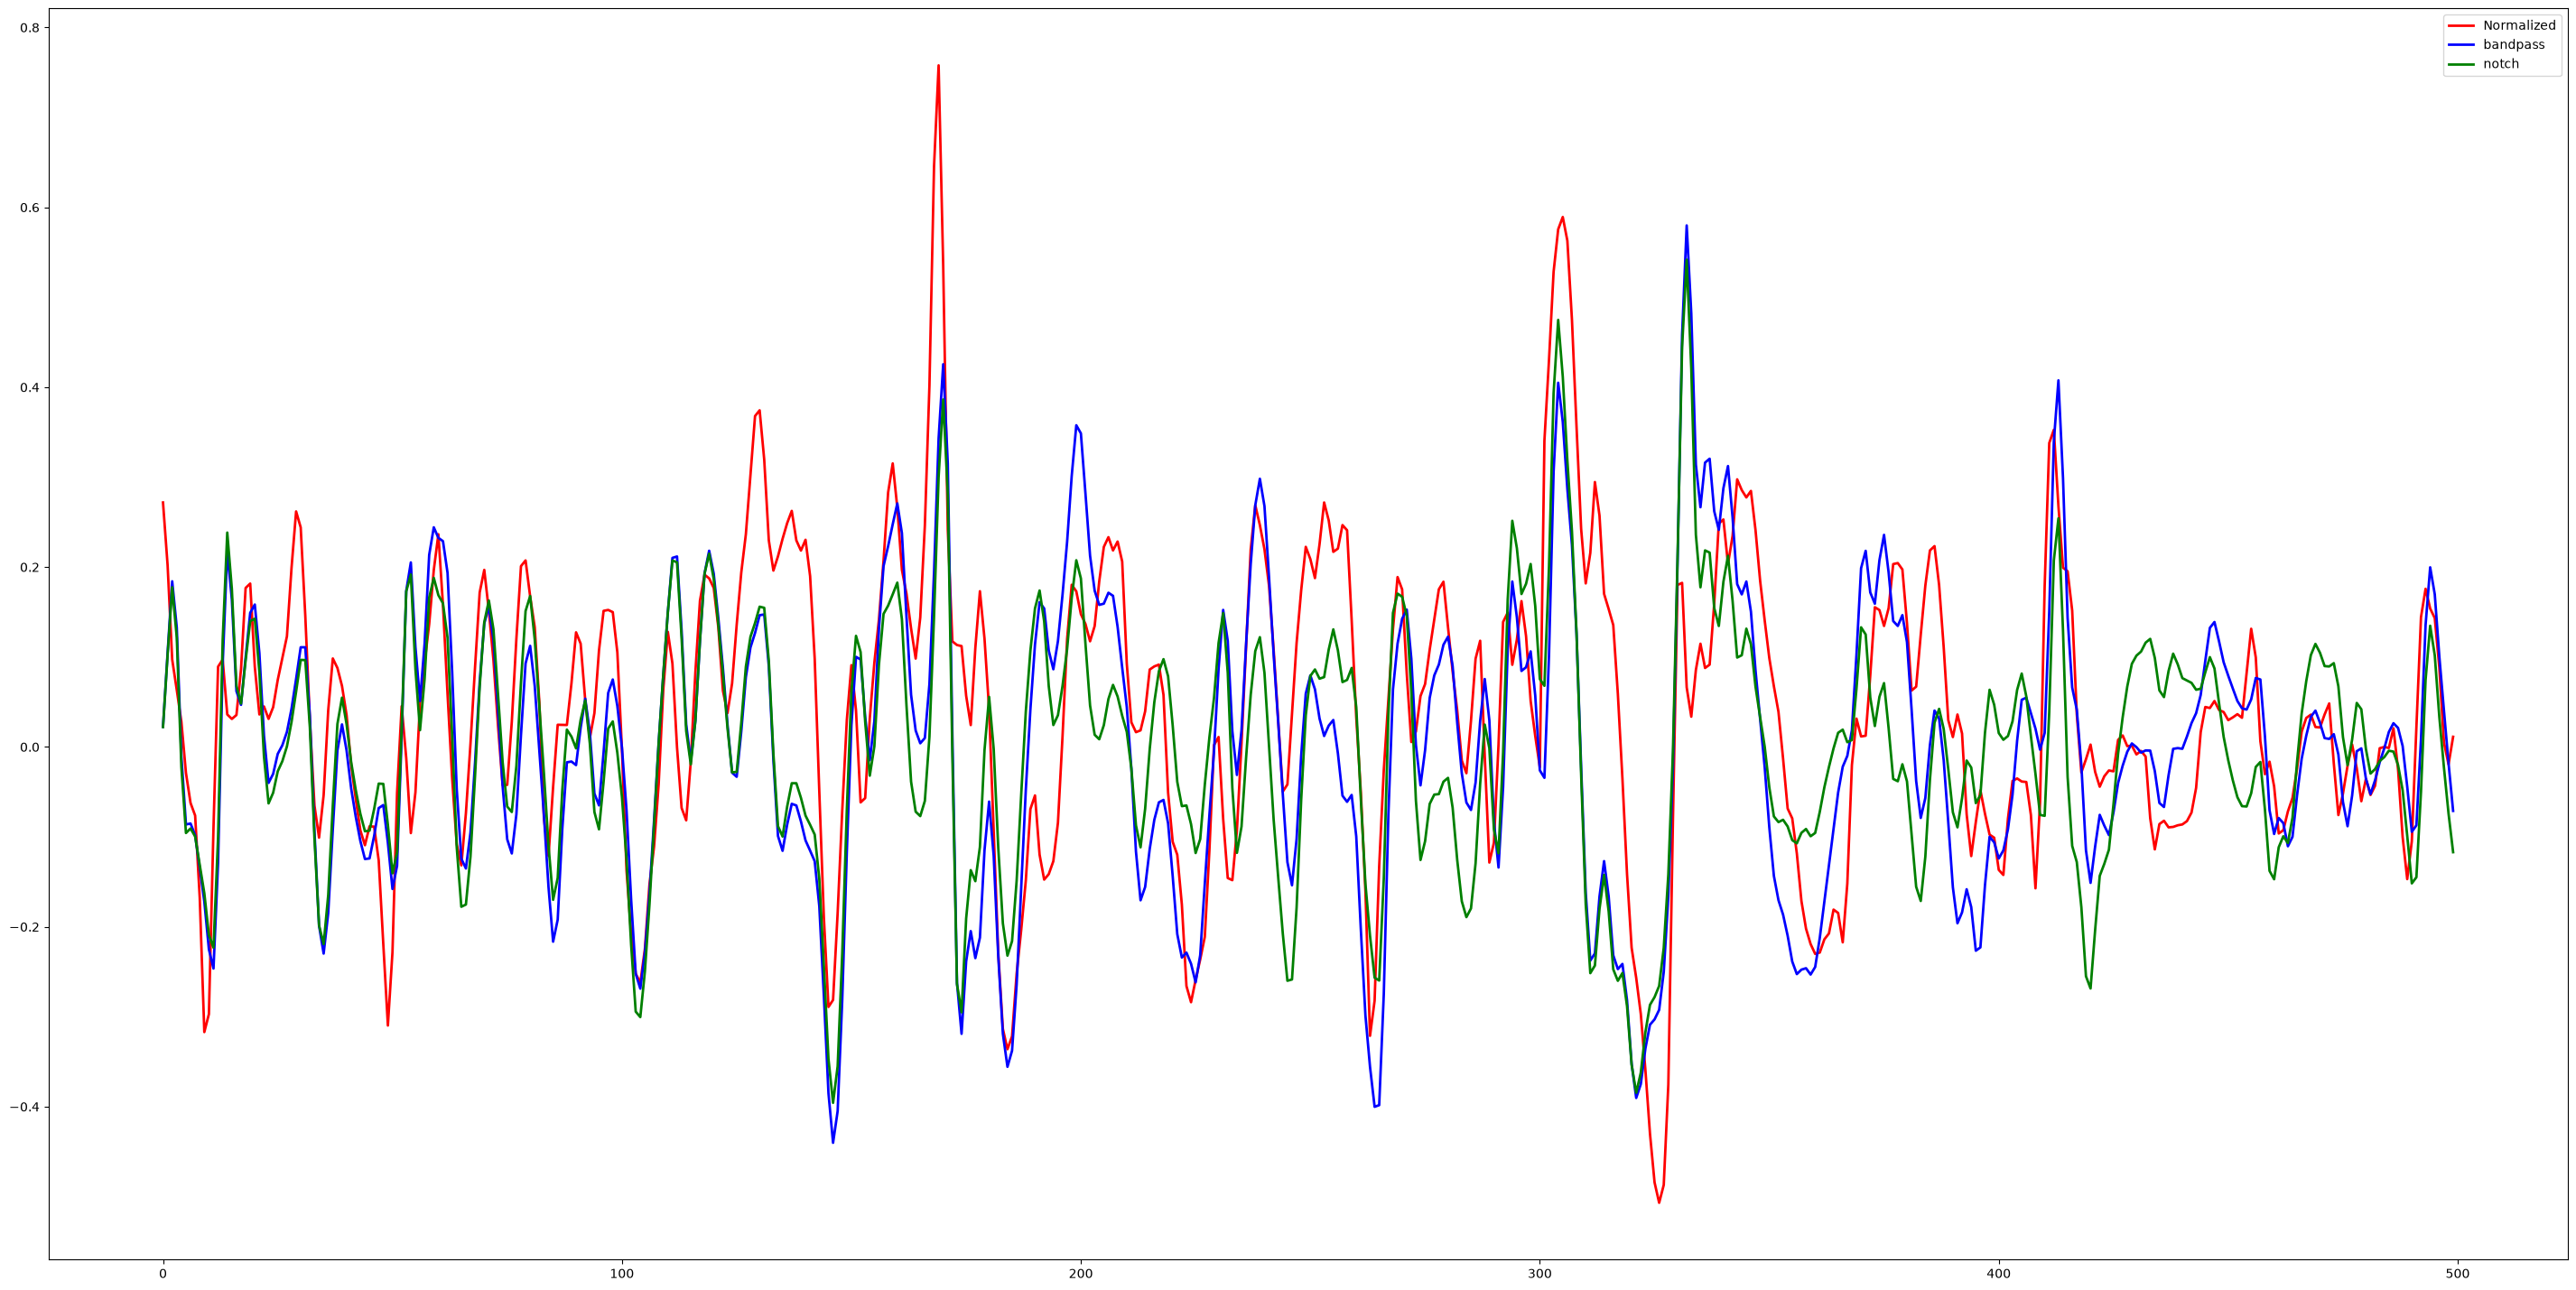

SNR Before Notch: 26.56 dB
SNR After Notch: 37.99 dB


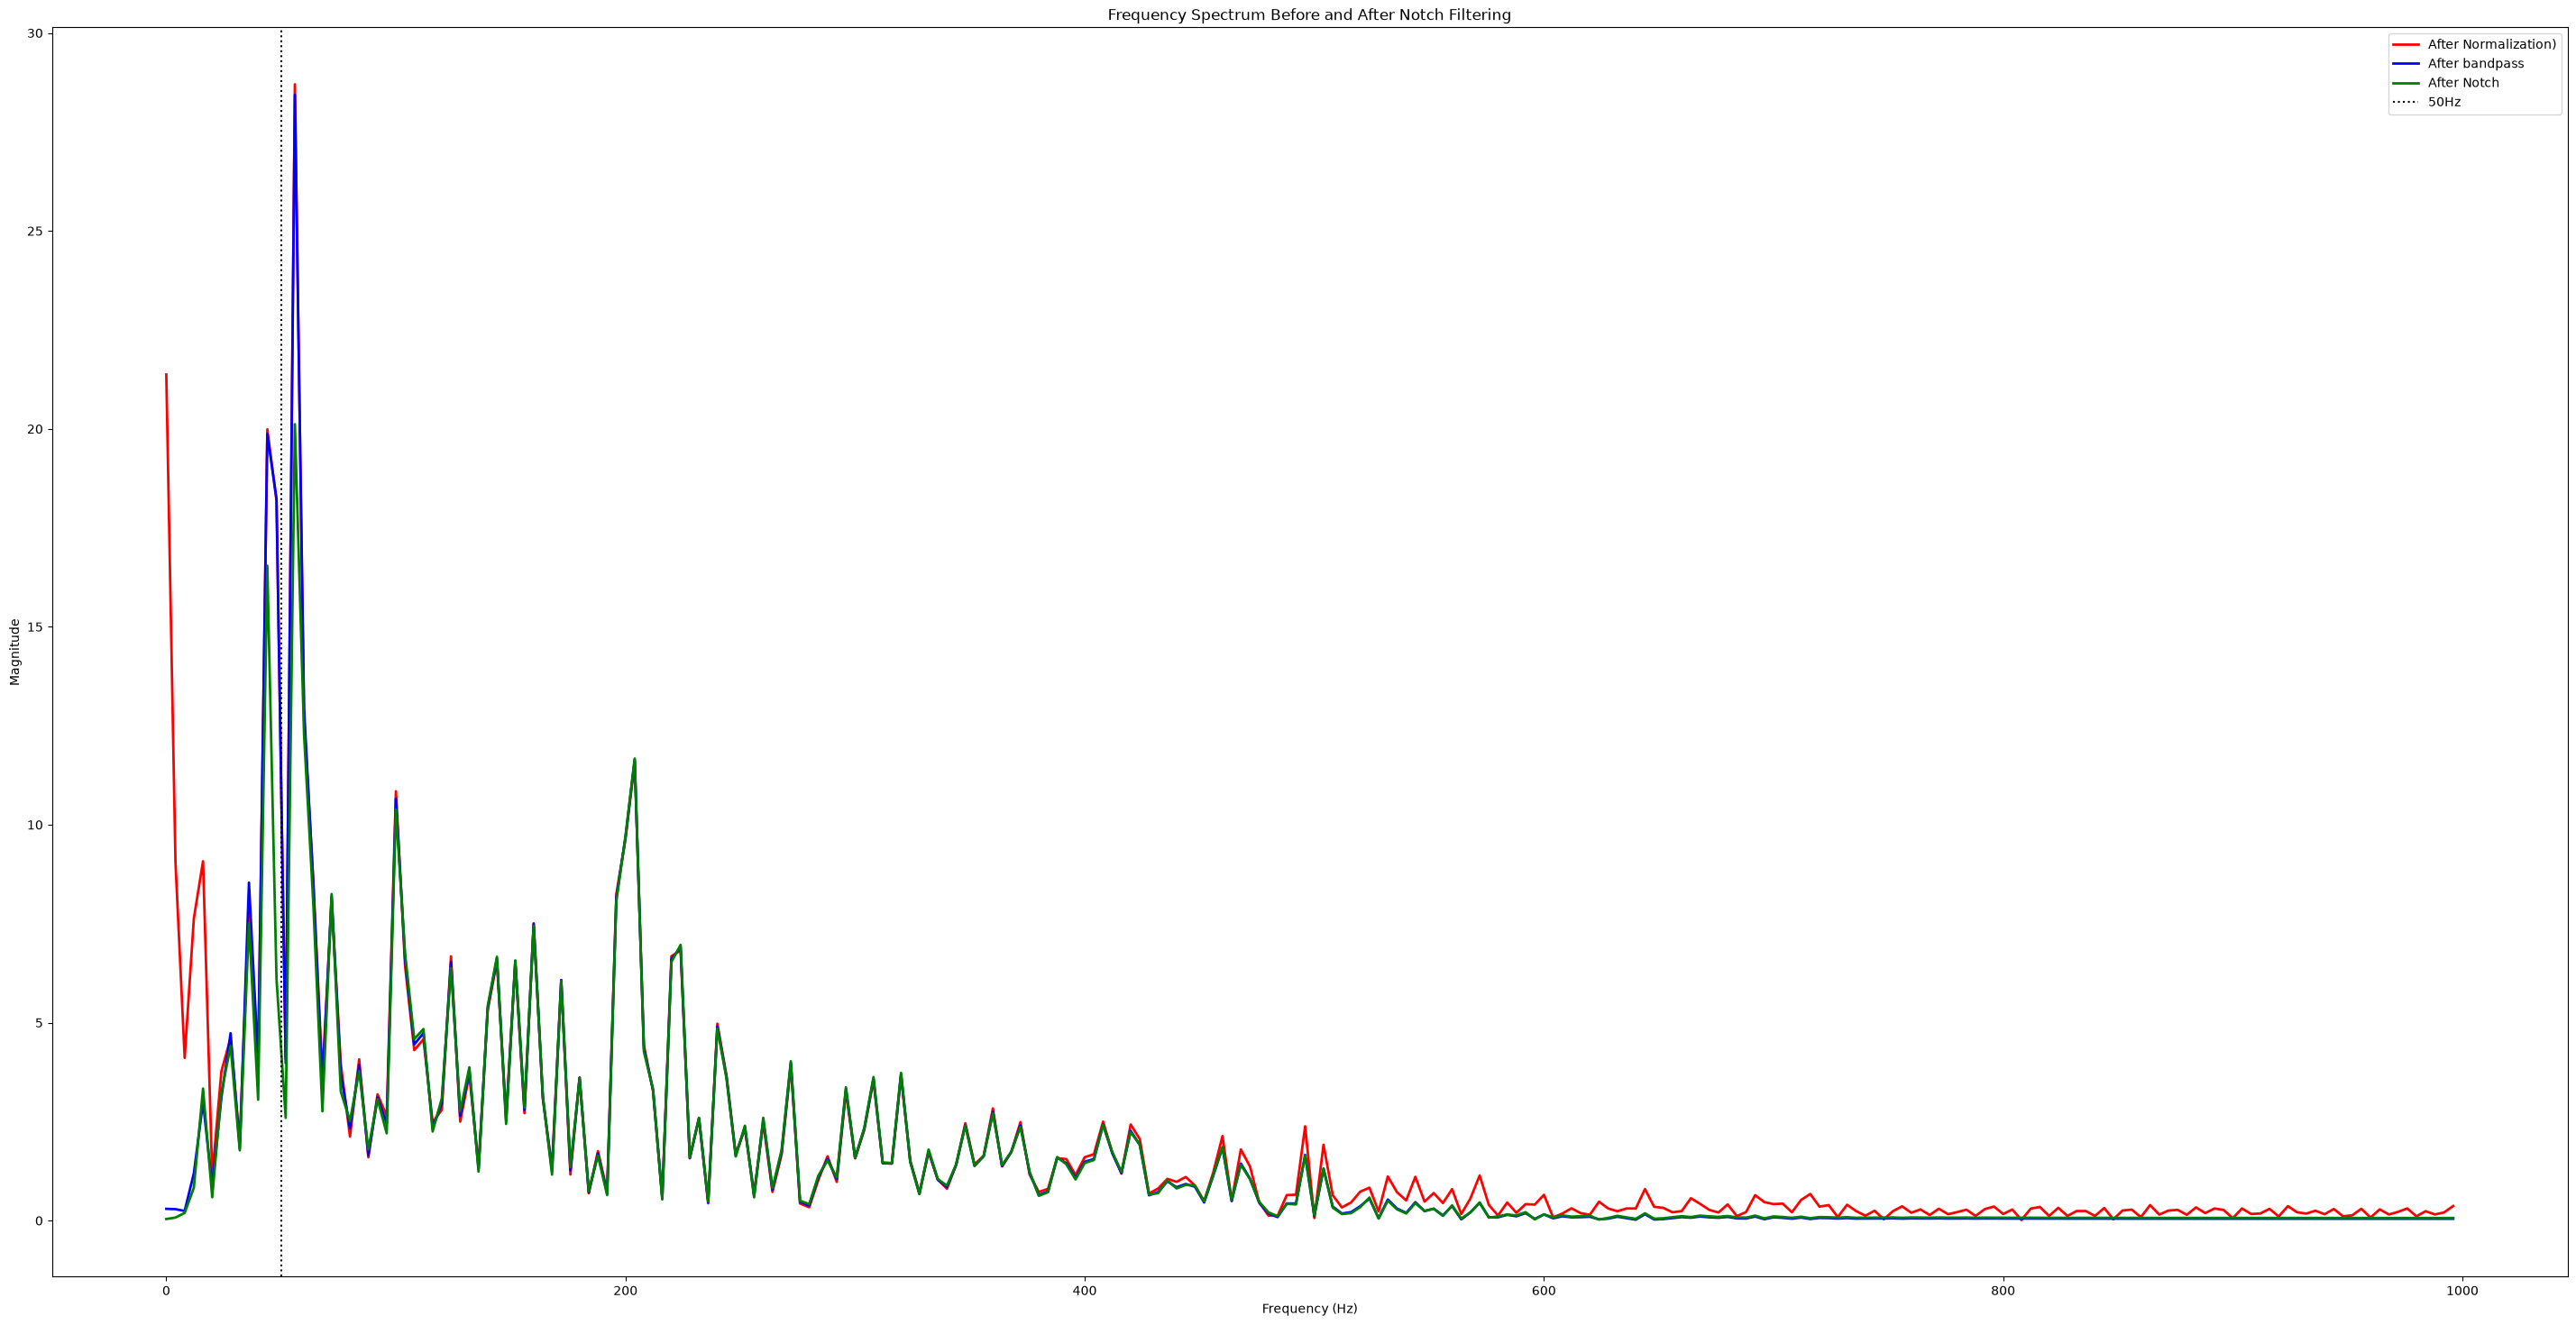

Saved preprocessed data to: db2_processed/S10_E1_A1_300_200_N.mat


In [2]:
import os
import glob
import numpy as np
from scipy.io import savemat
import pywt
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt  # Import matplotlib for plotting
# Import functions from your ninapro preprocessing library.
channel_idx =0  # Choose the channel to visualize
from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq
from nina_funcs import (
    get_data,
    normalise,
    filter_data,
    notch_filter,
    windowing,
    get_categorical,
    rectify,
)



def compute_snr(signal, noise_freq=50, fs=2000):
    # Compute FFT
    fft_signal = np.abs(fft(signal.to_numpy()))
    freqs = fftfreq(len(signal), 1/fs)
    
    # Find power at noise frequency
    noise_power = np.sum(fft_signal[(freqs >= noise_freq-1) & (freqs <= noise_freq+1)]**2)
    total_power = np.sum(fft_signal**2)
    
    # Compute SNR
    snr = 10 * np.log10((total_power - noise_power) / noise_power)
    return snr

def process_subject_file(file_path, train_reps, test_reps, gestures, win_len, win_stride):
    """
    Process a single subject file.
    
    Parameters:
      file_path (str): Full path to the subject's .mat file.
      train_reps (list): List of training repetitions.
      test_reps (list): List of testing repetitions.
      gestures (list): List of gesture labels to classify.
      win_len (int): Window length (adjusted for sampling rate).
      win_stride (int): Window stride (adjusted for sampling rate).
    
    Returns:
      X_train, y_train_cat, X_test, y_test_cat: Processed data ready for the model.
    """
    data_path = os.path.dirname(file_path)
    file_name = os.path.basename(file_path)
    
    # Load raw data.
    data = get_data(data_path, file_name)





    # Normalize using only training repetitions.
    data_normalized = normalise(data, train_reps)


    # Apply a bandpass filter (20-40 Hz).
    data_filtered = filter_data(data_normalized, f=(20,500), butterworth_order=4, btype='bandpass')

    
    
    # Rectify the signal.
    #data_rectified = rectify(data_filtered)


    # Remove 50 Hz interference with a notch filter.
    data_notch = notch_filter(data=data_filtered, f0=50, Q=5, fs=2000)





 






    #plot signal after normalizing and after notch and after bandpass
    plt.figure(figsize=(36,18))
    plt.plot(data_normalized.iloc[:500, channel_idx], label="Normalized", color="red", linestyle="solid", linewidth=2)
    plt.plot(data_filtered.iloc[:500, channel_idx], label="bandpass", color="blue", linestyle="solid", linewidth=2)
    plt.plot(data_notch.iloc[:500, channel_idx], label="notch", color="green", linestyle="solid", linewidth=2)
    #plt.plot(data_denoised.iloc[:500, channel_idx], label="wavelet", color="blue", linestyle="solid", linewidth=3)
    plt.legend()
    plt.show()





    #snr computing to see effectivness of the notch, snr_after should increase
    snr_before =  compute_snr(data_normalized.iloc[:5000, channel_idx])
    snr_after =  compute_snr(data_notch.iloc[:5000, channel_idx])
    print(f"SNR Before Notch: {snr_before:.2f} dB")
    print(f"SNR After Notch: {snr_after:.2f} dB")











    # A good notch filter should significantly reduce 50 Hz interference while keeping other frequencies intact.=, we plot the powe specturem, before notvh a clear peak at 50hz, after it reduced
    fs = 2000  # Sampling frequency (Hz)
    N = 500   # Number of samples (adjust as needed)
    # Compute FFT for Normalized and Notch Filtered signals
    freqs = fftfreq(N, 1/fs)  # Frequency axis
    fft_normalized = np.abs(fft(data_normalized.iloc[:N, channel_idx].to_numpy()))
    fft_filtered = np.abs(fft(data_filtered.iloc[:N, channel_idx].to_numpy()))
    fft_notched = np.abs(fft(data_notch.iloc[:N, channel_idx].to_numpy()))
    #fft_wavelet = np.abs(fft(data_denoised.iloc[:N, channel_idx].to_numpy()))

    # Plot frequency response
    plt.figure(figsize=(36, 18))
    plt.plot(freqs[:N//2], fft_normalized[:N//2], label="After Normalization)", color="red", linestyle="solid", linewidth=2)
    plt.plot(freqs[:N//2], fft_filtered[:N//2], label="After bandpass", color="blue", linestyle="solid", linewidth=2)
    plt.plot(freqs[:N//2], fft_notched[:N//2], label="After Notch", color="green", linestyle="solid", linewidth=2)
    #plt.plot(freqs[:N//2], fft_wavelet[:N//2], label="After wavlet", color="blue", linestyle="solid", linewidth=3)
    plt.axvline(x=50, color='black', linestyle="dotted", label="50Hz")
    plt.legend()
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title("Frequency Spectrum Before and After Notch Filtering")
    plt.show()







    # Segment the data into windows.
    X_train, y_train, _ = windowing(data_notch, train_reps, gestures, win_len, win_stride)
    X_test, y_test, _   = windowing(data_notch, test_reps, gestures, win_len, win_stride)
    
    # Convert labels to one-hot encoding.
    y_train_cat = get_categorical(y_train)
    y_test_cat = get_categorical(y_test)
    
    return X_train, y_train_cat, X_test, y_test_cat




def main():
    
    input_folder = 'db2_sb10/'
    output_folder = 'db2_processed/'
    os.makedirs(output_folder, exist_ok=True)
    
    # Find subject files matching pattern 
    subject_files = glob.glob(os.path.join(input_folder, 'S*_E1_A1.mat'))
    if not subject_files:
        print("No subject files found in the specified directory.")
        return
    
    # Define processing parameters.
    gestures = [ 1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17]
    train_reps = [1, 2, 4, 6]
    test_reps = [3, 5]
    
    win_len = 300
    win_stride = 200
    
    # Process each subject file.
    for file_path in subject_files:
        print(f"Processing file: {file_path}")
        X_train, y_train_cat, X_test, y_test_cat = process_subject_file(
            file_path, train_reps, test_reps, gestures, win_len, win_stride
        )
        
        # Build output filename.
        base_name = os.path.splitext(os.path.basename(file_path))[0]  
        # Extract subject identifier (assumed to be like "S1") and construct new name.
        subject_id = base_name.split('_')[0]  # "S1"
        output_filename = f"{subject_id}_E1_A1_300_200_N.mat"
        output_filepath = os.path.join(output_folder, output_filename)
        
        # Create dictionary with keys expected by your model code.
        out_data = {
            'train_data': X_train,
            'train_labels': y_train_cat,
            'test_data': X_test,
            'test_labels': y_test_cat
        }
        
        savemat(output_filepath, out_data)
        print(f"Saved preprocessed data to: {output_filepath}")

if __name__ == "__main__":
    main()